# QCut vs qiskit-addon-cutting

Load env with `uv sync --group benchmark`.

In [2]:
import math
from time import perf_counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit
from qiskit.circuit.library import RXXGate, RZZGate
from qiskit.quantum_info import PauliList, SparsePauliOp
from qiskit_addon_cutting import (
    DeviceConstraints,
    OptimizationParameters,
    cut_wires,
    expand_observables,
    find_cuts,
    generate_cutting_experiments,
    partition_problem,
)
from qiskit_addon_cutting.instructions import CutWire

import QCut as ck
from QCut import CutOptions, cut, cutGate


## Circuit families

Each returns the circuit marked for QCut, the circuit for the addon, and how the addon should split it. The cuts land in the same places for both.
`mixed_axes` is here because on single axis QCut will win on the joint decomposition for parallel rotations but for mixed axes this is not possible.
On `mixed_axes` QCut wins due to `consolidate` merging consecutive cut gates.

In [ ]:
def single_z(width):
    return SparsePauliOp(["I" * (width - 1 - i) + "Z" + "I" * i for i in range(width)])


def parallel_rotations(pairs):
    """`pairs` rotation gates crossing one split, all schedulable at once."""
    width = 2 * pairs
    marked, plain = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, plain):
        for q in range(width):
            c.ry(0.3 + 0.1 * q, q)
        # holds each half together, or the circuit falls into single-qubit pieces
        for q in range(pairs - 1):
            c.rzz(0.4, q, q + 1)
            c.rzz(0.4, pairs + q, pairs + q + 1)
    for i in range(pairs):
        marked.append(**cutGate(RZZGate(0.5 + 0.15 * i), i, pairs + i))
        plain.rzz(0.5 + 0.15 * i, i, pairs + i)
    return marked, plain, "A" * pairs + "B" * pairs, False


def parallel_wires(wires):
    """`wires` wires cut at the same point."""
    width = wires + 2
    marked, addon = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, addon):
        c.h(0)
        for q in range(1, wires + 1):
            c.cx(0, q)
    for q in range(1, wires + 1):
        marked.append(cut(), [q])
        addon.append(CutWire(), [q])
    for c in (marked, addon):
        for q in range(1, wires + 1):
            c.cx(q, width - 1)
    return marked, addon, None, True


def qaoa_layer(nodes, degree=3, seed=7):
    """One QAOA layer on a random regular graph, split down the middle."""
    graph = nx.random_regular_graph(degree, nodes, seed=seed)
    half = nodes // 2
    marked, plain = QuantumCircuit(nodes), QuantumCircuit(nodes)
    for c in (marked, plain):
        for q in range(nodes):
            c.h(q)
    for a, b in graph.edges():
        plain.rzz(0.8, a, b)
        if (a < half) != (b < half):
            marked.append(**cutGate(RZZGate(0.8), a, b))
        else:
            marked.rzz(0.8, a, b)
    for c in (marked, plain):
        for q in range(nodes):
            c.rx(0.6, q)
    return marked, plain, "A" * half + "B" * (nodes - half), False


def mixed_axes(pairs):
    """rzz then rxx on each crossing pair: the product is a generic unitary, so it
    cannot be bundled and consolidation matters."""
    width = 2 * pairs
    marked, plain = QuantumCircuit(width), QuantumCircuit(width)
    for c in (marked, plain):
        for q in range(width):
            c.ry(0.3 + 0.1 * q, q)
        for q in range(pairs - 1):
            c.rzz(0.4, q, q + 1)
            c.rzz(0.4, pairs + q, pairs + q + 1)
    for i in range(pairs):
        marked.append(**cutGate(RZZGate(0.7), i, pairs + i))
        marked.append(**cutGate(RXXGate(0.9), i, pairs + i))
        plain.rzz(0.7, i, pairs + i)
        plain.rxx(0.9, i, pairs + i)
    return marked, plain, "A" * pairs + "B" * pairs, False


FAMILIES = {
    "parallel rotations": (parallel_rotations, [1, 2, 3]),
    "parallel wires": (parallel_wires, [1, 2, 3]),
    "QAOA layer": (qaoa_layer, [6, 8, 10]),
    "mixed axes": (mixed_axes, [1, 2]),
}

## Same cuts, both libraries

In [3]:
def run_qcut(marked, observables, options=None):
    t = perf_counter()
    circuit = ck.get_locations_and_subcircuits(marked.copy(), options=options)
    experiment = ck.get_experiment_circuits(circuit, observables)
    return float(experiment.gamma), int(experiment.num_circuits), perf_counter() - t


def run_addon(circuit, observables, labels, wire_cuts):
    paulis = PauliList([p.to_label() for p in observables.paulis])
    t = perf_counter()
    if wire_cuts:
        expanded = cut_wires(circuit)
        problem = partition_problem(
            circuit=expanded,
            observables=expand_observables(paulis, circuit, expanded),
        )
    else:
        problem = partition_problem(
            circuit=circuit, partition_labels=labels, observables=paulis
        )
    subexperiments, coefficients = generate_cutting_experiments(
        circuits=problem.subcircuits,
        observables=problem.subobservables,
        num_samples=np.inf,
    )
    # the coefficient 1-norm, not prod(basis.overhead), which would be gamma squared
    gamma = float(sum(abs(w) for w, _ in coefficients))
    count = int(sum(len(g) for g in subexperiments.values()))
    return gamma, count, perf_counter() - t


rows = []
for family, (build, sizes) in FAMILIES.items():
    for size in sizes:
        marked, addon, labels, wire_cuts = build(size)
        observables = single_z(marked.num_qubits)
        for library, (gamma, count, seconds) in (
            ("QCut", run_qcut(marked, observables)),
            ("addon", run_addon(addon, observables, labels, wire_cuts)),
        ):
            rows.append(
                {
                    "family": family,
                    "size": size,
                    "library": library,
                    "gamma": gamma,
                    "circuits": count,
                    "seconds": seconds,
                }
            )

same = pd.DataFrame(rows)
same["shots"] = same["gamma"] ** 2
same

,family,size,library,gamma,circuits,seconds,shots
0,parallel rotations,1,QCut,1.958851,12,0.015015,3.837098
1,parallel rotations,1,addon,1.958851,12,0.004384,3.837098
2,parallel rotations,2,QCut,3.749508,60,0.041748,14.058807
3,parallel rotations,2,addon,4.329791,72,0.010840,18.747092
4,parallel rotations,3,QCut,7.156596,264,0.217713,51.216862
5,parallel rotations,3,addon,10.541795,432,0.079489,111.129448
6,parallel wires,1,QCut,4.000000,16,0.004145,16.000000
7,parallel wires,1,addon,4.000000,16,0.003137,16.000000
8,parallel wires,2,QCut,7.000000,56,0.016999,49.000000
9,parallel wires,2,addon,16.000000,128,0.019933,256.000000


In [4]:
wide = same.pivot_table(index=["family", "size"], columns="library", values=["gamma", "circuits"])
ratio = pd.DataFrame(
    {
        "gamma QCut/addon": wide["gamma"]["QCut"] / wide["gamma"]["addon"],
        "shots QCut/addon": (wide["gamma"]["QCut"] / wide["gamma"]["addon"]) ** 2,
        "circuits QCut/addon": wide["circuits"]["QCut"] / wide["circuits"]["addon"],
    }
)
ratio.round(3)

gamma QCut/addon  shots QCut/addon  \
family             size                                       
QAOA layer         6                1.000             1.000   
                   8                1.000             1.000   
                   10               1.000             1.000   
mixed axes         1                0.828             0.686   
                   2                0.686             0.470   
parallel rotations 1                1.000             1.000   
                   2                0.866             0.750   
                   3                0.679             0.461   
parallel wires     1                1.000             1.000   
                   2                0.438             0.191   
                   3                0.234             0.055   

                         circuits QCut/addon  
family             size                       
QAOA layer         6                   0.110  
                   8                   0.020  
                   10                  0.005  
mixed axes         1                   0.833  
                   2                   0.694  
parallel rotations 1                   1.000  
                   2                   0.833  
                   3                   0.611  
parallel wires     1                   1.000  
                   2                   0.438  
                   3                   0.234

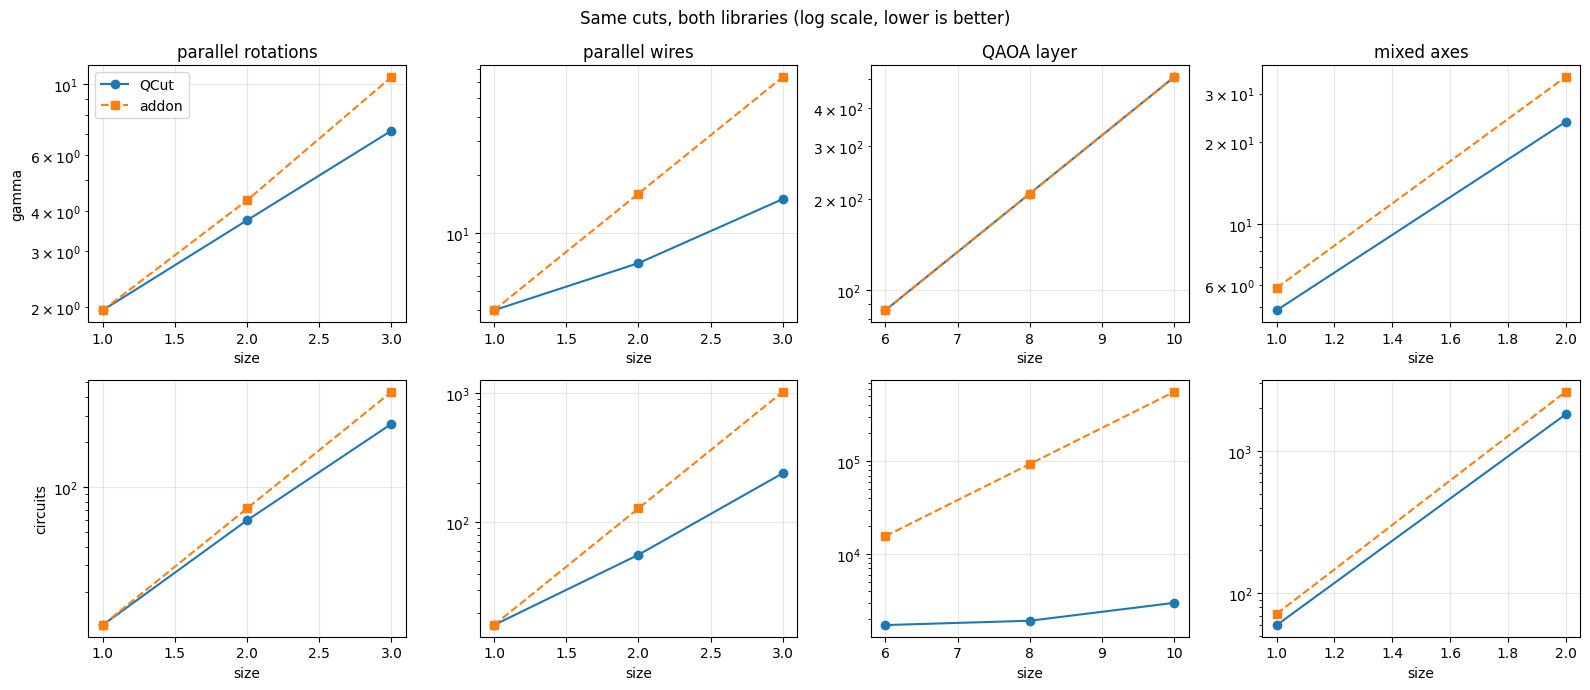

In [5]:
families = list(FAMILIES)
fig, axes = plt.subplots(2, len(families), figsize=(4 * len(families), 7), sharex=False)

for column, family in enumerate(families):
    block = same[same.family == family]
    for row, metric in enumerate(("gamma", "circuits")):
        ax = axes[row, column]
        for library, marker in (("QCut", "o-"), ("addon", "s--")):
            part = block[block.library == library].sort_values("size")
            ax.plot(part["size"], part[metric], marker, label=library)
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(family)
        if column == 0:
            ax.set_ylabel(metric)
        ax.set_xlabel("size")

axes[0, 0].legend()
fig.suptitle("Same cuts, both libraries (log scale, lower is better)")
fig.tight_layout()

## Which QCut option is responsible

The addon has no equivalent of consolidation, joint rotation cutting or of communicating wire cuts, so turning them off should reproduce its numbers.

In [ ]:
off = CutOptions(joint_rotation_cuts=False, wire_cut_communication="never", consolidate="never")

rows = []
for family, (build, sizes) in FAMILIES.items():
    for size in sizes:
        marked, addon, labels, wire_cuts = build(size)
        observables = single_z(marked.num_qubits)
        default_gamma, default_count, _ = run_qcut(marked, observables)
        plain_gamma, plain_count, _ = run_qcut(marked, observables, off)
        addon_gamma, addon_count, _ = run_addon(addon, observables, labels, wire_cuts)
        rows.append(
            {
                "family": family,
                "size": size,
                "addon": addon_gamma,
                "qcut_features_off": plain_gamma,
                "qcut_default": default_gamma,
            }
        )

attribution = pd.DataFrame(rows)
attribution["off == addon"] = np.isclose(
    attribution["qcut_features_off"], attribution["addon"], rtol=1e-6
)
attribution.round(4)

,family,size,addon,qcut_features_off,qcut_default,off == addon
0,parallel rotations,1,1.9589,1.9589,1.9589,True
1,parallel rotations,2,4.3298,4.3298,3.7495,True
2,parallel rotations,3,10.5418,10.5418,7.1566,True
3,parallel wires,1,4.0000,4.0000,4.0000,True
4,parallel wires,2,16.0000,16.0000,7.0000,True
5,parallel wires,3,64.0000,64.0000,15.0000,True
6,QAOA layer,6,85.5536,85.5536,85.5536,True
7,QAOA layer,8,208.2983,208.2983,208.2983,True
8,QAOA layer,10,507.1465,507.1465,507.1465,True
9,mixed axes,1,5.8736,5.8736,4.8644,True


## Automatic cut finding

Each library picks its own cuts under the same qubit budget. Gamma is what it settled on, time is how long it took to decide.

In [4]:
def finder_circuit(nodes, degree=3, seed=11):
    graph = nx.random_regular_graph(degree, nodes, seed=seed)
    circuit = QuantumCircuit(nodes)
    for q in range(nodes):
        circuit.h(q)
    for a, b in graph.edges():
        circuit.rzz(0.8, a, b)
    for q in range(nodes):
        circuit.rx(0.6, q)
    return circuit


rows = []
for nodes in (6, 8, 10, 12, 20, 60, 100):
    circuit = finder_circuit(nodes)
    budget = nodes // 2

    t = perf_counter()
    found = ck.find_cuts(circuit.copy(), options=CutOptions(finder_max_qubits=budget, seed=0))
    experiment = ck.get_experiment_circuits(found, single_z(nodes))
    rows.append(
        {"nodes": nodes, "library": "QCut", "gamma": float(experiment.gamma),
             "cuts": len(found.cut_locations), "seconds": perf_counter() - t}
    )

    t = perf_counter()
    _, metadata = find_cuts(
        circuit.copy(),
        OptimizationParameters(seed=0),
        DeviceConstraints(qubits_per_subcircuit=budget),
    )
    # sampling_overhead is gamma squared
    rows.append(
        {"nodes": nodes, "library": "addon", "gamma": math.sqrt(metadata["sampling_overhead"]),
             "cuts": len(metadata.get("cuts", [])), "seconds": perf_counter() - t}
    )

finder = pd.DataFrame(rows)
finder.round(4)

,nodes,library,gamma,cuts,seconds
0,6,QCut,1.443250e+01,3,0.5158
1,6,addon,1.443250e+01,3,0.0099
2,8,QCut,3.513910e+01,4,0.4313
3,8,addon,3.513910e+01,4,0.0651
4,10,QCut,7.069960e+01,5,1.0201
5,10,addon,8.555360e+01,5,0.5753
6,12,QCut,2.903820e+01,4,0.4839
7,12,addon,3.513910e+01,4,0.6051
8,20,QCut,1.422471e+02,6,1.5448
9,20,addon,7.319414e+03,10,7.6794


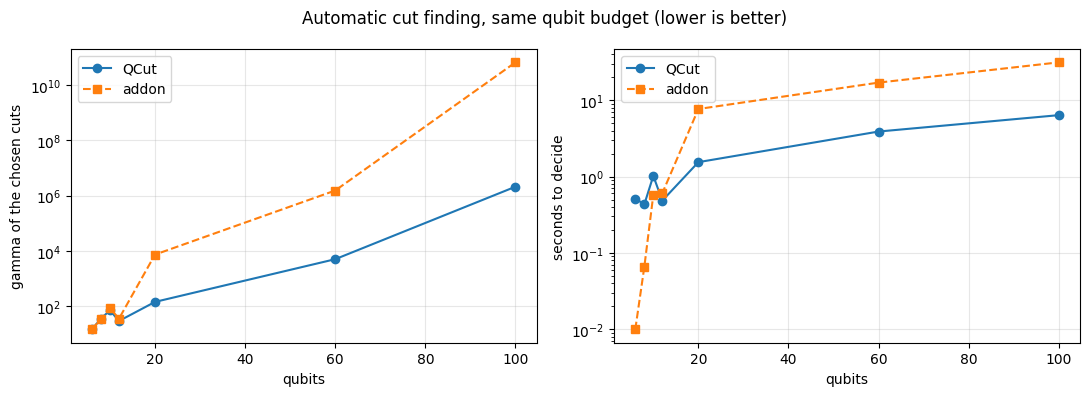

In [5]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
for library, marker in (("QCut", "o-"), ("addon", "s--")):
    part = finder[finder.library == library].sort_values("nodes")
    left.plot(part["nodes"], part["gamma"], marker, label=library)
    right.plot(part["nodes"], part["seconds"], marker, label=library)

left.set(xlabel="qubits", ylabel="gamma of the chosen cuts", yscale="log")
right.set(xlabel="qubits", ylabel="seconds to decide", yscale="log")
for ax in (left, right):
    ax.grid(True, alpha=0.3)
    ax.legend()
fig.suptitle("Automatic cut finding, same qubit budget (lower is better)")
fig.tight_layout()

## What each library has that the other does not

| | QCut | addon |
| --- | --- | --- |
| Joint cutting of parallel rotation gates | yes | no |
| Wire cuts with classical communication | yes | no |
| Merging consecutive gates on a pair before cutting | yes | no |
| Generic two-qubit gate cut from the gate's own matrix | yes | yes |
| Automatic cut finding | yes | yes |
| Cut finding under a qubit budget | yes | yes |
| Sampling instead of full enumeration | yes | yes |
| Runs on IQM hardware directly | yes | via transpilation |
| Qiskit primitives / Runtime integration | no | yes |
| Cut finding with an explicit gamma ceiling | no | yes (`max_gamma`) |